Obiettivo del progetto
L'obiettivo è esplorare due metodologie distinte (DBSCAN e Elbow Method tramite Inertia/WCSS) per determinare il numero ottimale di cluster k su un dataset non etichettato. Successivamente, si applicherà l'algoritmo K-Means utilizzando il valore di k identificato. Per questo esercizio verrà utilizzato il dataset Iris, ignorando le etichette di classe originali.

1) Data Exploration & Preprocessing
    * Caricamento e Analisi: Carica il dataset e fornire un'analisi descrittiva iniziale (es. df.describe())
    * Standarizzazione: Applicare la standarizzazione della feature (X) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria.

2) Stima di k con DBSCAN
Eseguire l'algoritmo DBSCAN iterativamente per analizzare la struttura dei dati basati sulla densità.
    * Parametri di iterazione: min_samples=5 eps in [0.35,0.45,0.55]
    * min_samples=5
    * eps in [0.35,0.45,0.55]
    * Metriche da determinare per ogni esecuzione: il numero di cluster k identificati. Il numero di punto rumorosi (label -1)
    * Il numero di cluster k identificati
    * Il numero di punti rumorosi (label -1)
    * Selezione: individuare il numero di cluster k più plausibile tra i risultati ottenuti.

3) Stima di k con Elbow Method
Utilizzare K-Means per identificare il k ottimale analizzando l'inerzia (o WCSS: Within Cluster Sum of Squares)
    * Configurazione: Algoritmo: K-Means. Range di k da 1 a 10
    * Algoritmo : K-Means
    * Range di k da 1 a 10
    * Visualizzazione: Plot del grafico dell'Elbow Method (Inerzia sull'asse Y e k sull'asse X). Identificazione del 'punto di gomito' (dove la curva si piega). Inserimento di un asse verticale in corrispondenza del valore x=k scelto.
    * Plot del grafico dell'Elbow Method (Inerzia sull'asse Y e k sull'asse X)
    * Identificazione del 'punto di gomito' (dove la cura si piega)
    * Inserimento di un asse verticale in corrispondenza del valore x=k scelto

4) Applicazione Finale & Visualizzazione
    * Clusterizzazione Definitiva: Stabilire il k finale e applicare  il K-Means sul dataset standarizzato.
    * Valutazione: Calcolare il Silhouette Score per valutare la coesione interna e la separazione del cluster.
    * Visualizzazione Risultati: Plot dei dati proiettati in 2D (utilizzando le prime due feature). Rappresentazione dei centroide dei cluster.
    * Plot dei dati proiettati in 2D (utilizzando le prime due feature)
    * Rappresentazione dei centroidi nei cluster

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

1) Data Exploration & Preprocessing
    * Caricamento e Analisi: Carica il dataset e fornire un'analisi descrittiva iniziale (es. df.describe())
    * Standarizzazione: Applicare la standarizzazione della feature (X) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria.

* Caricamento

In [3]:
iris=load_iris() #dataset
X,y=iris.data, iris.target #X=matrice delle feature y= tipi di iris, sono le label
feature_names=iris.feature_names #nomi delle colonne
n_feature=len(feature_names)
print(X.shape)
print(feature_names)

(150, 4)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


Analisi descrittiva

In [15]:
df = pd.DataFrame(X, columns=feature_names)
print(df.head())
print(df.describe())
df.info()

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000

* Standarizzazione

In [4]:
scaler=StandardScaler()
X_std=scaler.fit_transform(X)

2) Stima di k con DBSCAN
Eseguire l'algoritmo DBSCAN iterativamente per analizzare la struttura dei dati basati sulla densità.
    * Parametri di iterazione: min_samples=5 eps in [0.35,0.45,0.55]
    * min_samples=5
    * eps in [0.35,0.45,0.55]
    * Metriche da determinare per ogni esecuzione: il numero di cluster k identificati. Il numero di punto rumorosi (label -1)
    * Il numero di cluster k identificati
    * Il numero di punti rumorosi (label -1)
    * Selezione: individuare il numero di cluster k più plausibile tra i risultati ottenuti.

DBSCAN raggruppa i dati in base all'intensità, ha bisogno di due parametri fondamentali: eps (raggio massimo entro il quale i punti vengono considerati vicini), e min_samples (n. di punti minimo per formare una zona densa). 

In [32]:
lista_eps=[0.35,0.45,0.55]
min_samples=5
print("************")
print("** DBSCAN **")
print("************")
for eps in lista_eps:
    dbscan=DBSCAN(eps=eps, min_samples=min_samples)
    dbscan.fit(X_std)
    labels=dbscan.labels_
    n_clusters=len(set(labels))-(1 if -1 in labels else 0)
    assegnati=np.sum(labels != -1)
    totali=len(labels)
    noise=totali-assegnati
    print(f"EPS={eps} \n\tN. di cluster trovati: {n_clusters} \n\tN. di noise trovati: {noise} \n\tEtichettati: {assegnati} \n\tPercentuale assegnati: {assegnati/totali*100:.2f} ")

************
** DBSCAN **
************
EPS=0.35 
	N. di cluster trovati: 4 
	N. di noise trovati: 104 
	Etichettati: 46 
	Percentuale assegnati: 30.67 
EPS=0.45 
	N. di cluster trovati: 3 
	N. di noise trovati: 54 
	Etichettati: 96 
	Percentuale assegnati: 64.00 
EPS=0.55 
	N. di cluster trovati: 2 
	N. di noise trovati: 29 
	Etichettati: 121 
	Percentuale assegnati: 80.67 


Tra i valori eps testati 0.55 produce pochi punti noise e solo 2 cluster k=2 ben separati.

Metodo Silhoutte score per valutare i 3 k identificati dai valori eps testati

In [33]:
print("************")
print("** K-MEANS++ (Silhoutte score) **")
print("************")
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_std)
    score = silhouette_score(X_std, labels)
    print(f"k={k} -> silhouette score = {score:.4f}")

************
** K-MEANS++ (Silhoutte score) **
************
k=2 -> silhouette score = 0.5818
k=3 -> silhouette score = 0.4599
k=4 -> silhouette score = 0.3845


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Silhoutte misura quanto i cluster sono fatti bene, cioè quanto un punto è vicino ad un cluster, e quanto un punto è lontano dagli altri cluster.
Nell'esercizio il Silhouette Score è massimo per k=2, confermando quanto rilevato con DBSCAN (eps=5.5, n.cluster trovati=2)

3) Stima di k con Elbow Method
Utilizzare K-Means per identificare il k ottimale analizzando l'inerzia (o WCSS: Within Cluster Sum of Squares)
    * Configurazione: Algoritmo: K-Means. Range di k da 1 a 10
    * Algoritmo : K-Means
    * Range di k da 1 a 10
    * Visualizzazione: Plot del grafico dell'Elbow Method (Inerzia sull'asse Y e k sull'asse X). Identificazione del 'punto di gomito' (dove la curva si piega). Inserimento di un asse verticale in corrispondenza del valore x=k scelto.
    * Plot del grafico dell'Elbow Method (Inerzia sull'asse Y e k sull'asse X)
    * Identificazione del 'punto di gomito' (dove la cura si piega)
    * Inserimento di un asse verticale in corrispondenza del valore x=k scelto

In [36]:
print("************")
print("** K-MEANS++ (Inertia) **")
print("************")
wcss=[] #crea lista vuota (più i punti sono vicini al loro centroide, più WCSS è bassa)
k_values=range(1,11)  #crea i valori k da 1 a 10 
for k in k_values:  #per ogni k (da 1 a 10) provo il kmeans
    kmeans=KMeans(n_clusters=k,init='k-means++',random_state=42) #creo il metodo kmeans con k cluster
    kmeans.fit(X_std) #addestro il modello
    wcss.append(kmeans.inertia_)
print(wcss)

************
** K-MEANS++ (Inertia) **
************
[600.0, 222.36170496502308, 191.02473685317972, 114.35407164049779, 91.04766991109528, 81.55075699571756, 80.77773933734284, 64.42674849482268, 55.70690047933692, 51.121095396505545]


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: User

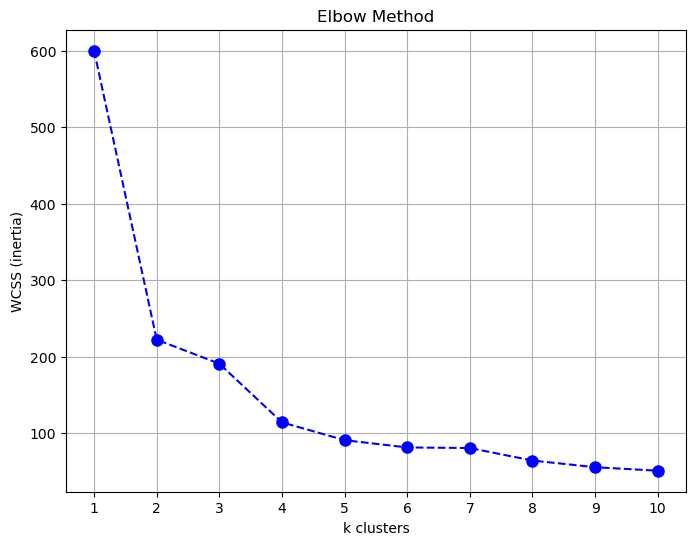

In [12]:
plt.figure(figsize=(8,6))
plt.plot(k_values,wcss,"o--",color="blue",markersize=8) #x=k y=wcss
plt.xlabel("k clusters")
plt.ylabel("WCSS (inertia)")
plt.xticks(k_values)
plt.title("Elbow Method")
plt.grid(True)
plt.show()

k valutabili tra 2 e 4, dbscan ha proposto k=2, silhouette k=2 Elbow Method evidenzia un salto importante con k=2, pertanto confermo k=2 

In [38]:
k=2

* Inserimento di un asse verticale in corrispondenza del valore x=k scelto

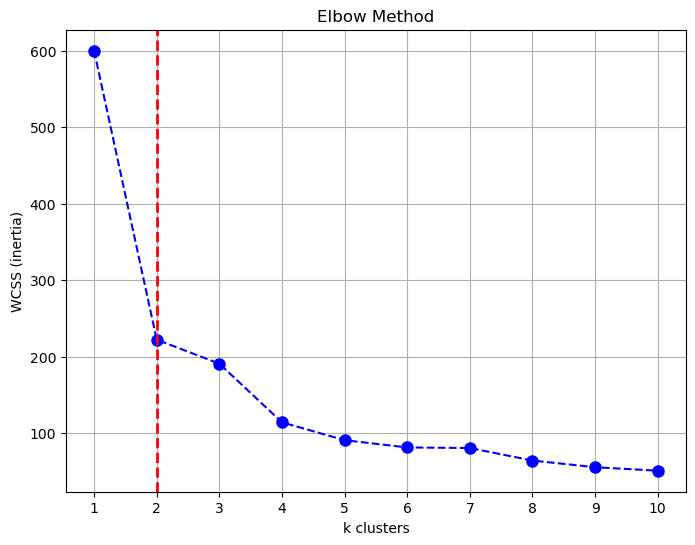

In [21]:
plt.figure(figsize=(8,6))
plt.plot(k_values,wcss,"o--",color="blue",markersize=8) #x=k y=wcss
plt.axvline(x=k, color='red', linestyle='--', linewidth=2)
plt.xlabel("k clusters")
plt.ylabel("WCSS (inertia)")
plt.xticks(k_values)
plt.title("Elbow Method")
plt.grid(True)
plt.show()

4) Applicazione Finale & Visualizzazione
    * Clusterizzazione Definitiva: Stabilire il k finale e applicare  il K-Means sul dataset standarizzato.
    * Valutazione: Calcolare il Silhouette Score per valutare la coesione interna e la separazione del cluster.
    * Visualizzazione Risultati: Plot dei dati proiettati in 2D (utilizzando le prime due feature). Rappresentazione dei centroide dei cluster.
    * Plot dei dati proiettati in 2D (utilizzando le prime due feature)
    * Rappresentazione dei centroidi nei cluster

avevo scelto k=2

In [40]:
kmeans=KMeans(n_clusters=k,init="k-means++",random_state=42)
clusters=kmeans.fit_predict(X_std)

centroids=kmeans.cluster_centers_ #salvo i centroidi finali (avendo 4 feature nel dataset originale, ogni centroide ha 4 valori)
iter=kmeans.n_iter_  #numero di iterazoini servite per convergere

print(f"Iteration: \t{iter}")
print(f"Centroidi: \n{centroids}")

Iteration: 	7
Centroidi: 
[[ 0.50728948 -0.42663134  0.65249366  0.62744675]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]]


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


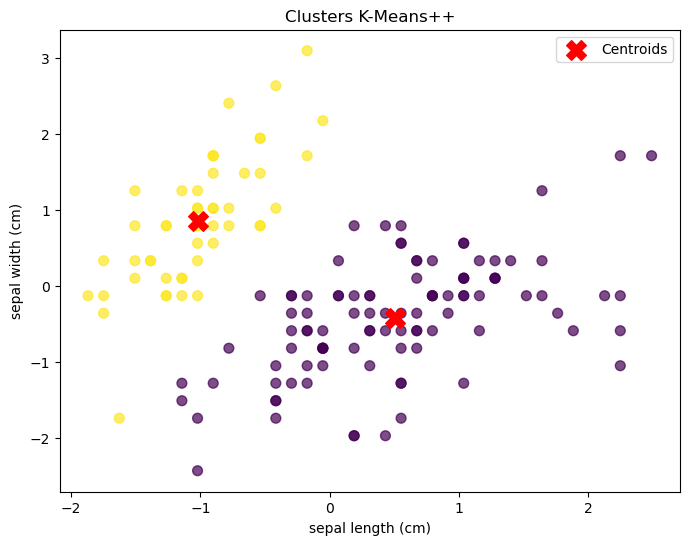

In [46]:

plt.figure(figsize=(8,6))
plt.scatter(X_std[:,0], X_std[:,1], c=clusters,cmap="viridis",s=50,alpha=0.7)
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c="red",
    s=200,
    marker="X",
    label="Centroids",
)
plt.title("Clusters K-Means++")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.show()